# **Notebook 02** - Limpeza e Tratamento dos Dados

### Objetivo

O objetivo deste notebook é realizar a limpeza e o tratamento do conjunto de dados consolidado da Cyclistic, preparando os dados para as etapas de análise exploratória, consultas SQL e visualização no Power BI.

Nesta etapa serão investigados possíveis problemas de qualidade e consistência dos dados, garantindo que as informações utilizadas nas análises sejam adequadas e confiáveis.

### Etapas

Neste notebook serão realizadas as seguintes etapas:

**1. Importação das bibliotecas necessárias;**<br>
**2. Carregamento do dataset consolidado;**<br>
**3. Inspeção Inicial com Sweetviz**<br>
**4. Verificação dos tipos de dados;**<br>
**5. Conversão e padronização das variáveis de data e hora;**<br>
**6. Identificação e tratamento de valores ausentes;**<br>
**7. Identificação e tratamento de registros duplicados;**<br>
**8. Verificação de inconsistências nos dados;**<br>
**9. Verificação de valores inválidos;**<br>
**10. Identificação e tratamento de outliers;**<br>
**11. Criação de novas variáveis para análise, incluindo o cálculo da duração das viagens;**<br>
**12. Validação do dataset após o tratamento;**<br>
**13. Salvamento do dataset processado.**

---

## 1. Importação das Bibliotecas

In [100]:
# Imports

import numpy as np
import pandas as pd
import seaborn as sns
import sweetviz as sv
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

---

## 2. Carregamento dos Dados

In [84]:
# Carrega o Dataset e cria o DataFrame

df = pd.read_csv("../data/processed/cyclistic_202509_202608.csv")

---

## 3. Inspeção Inicial com Sweetviz

                                             |          | [  0%]   00:00 -> (? left)

findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfo


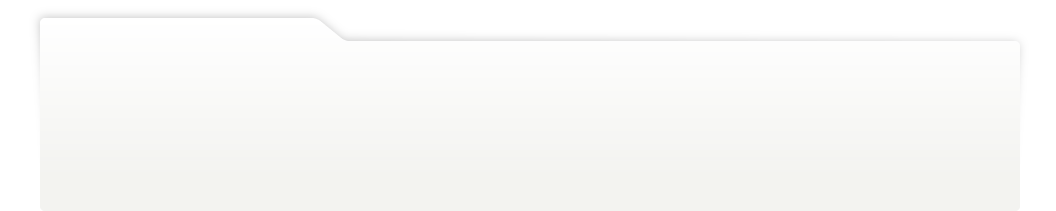
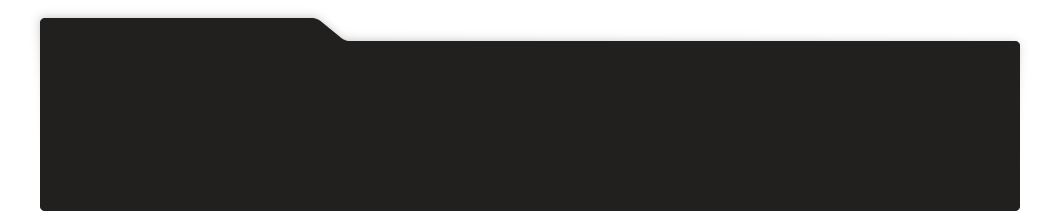
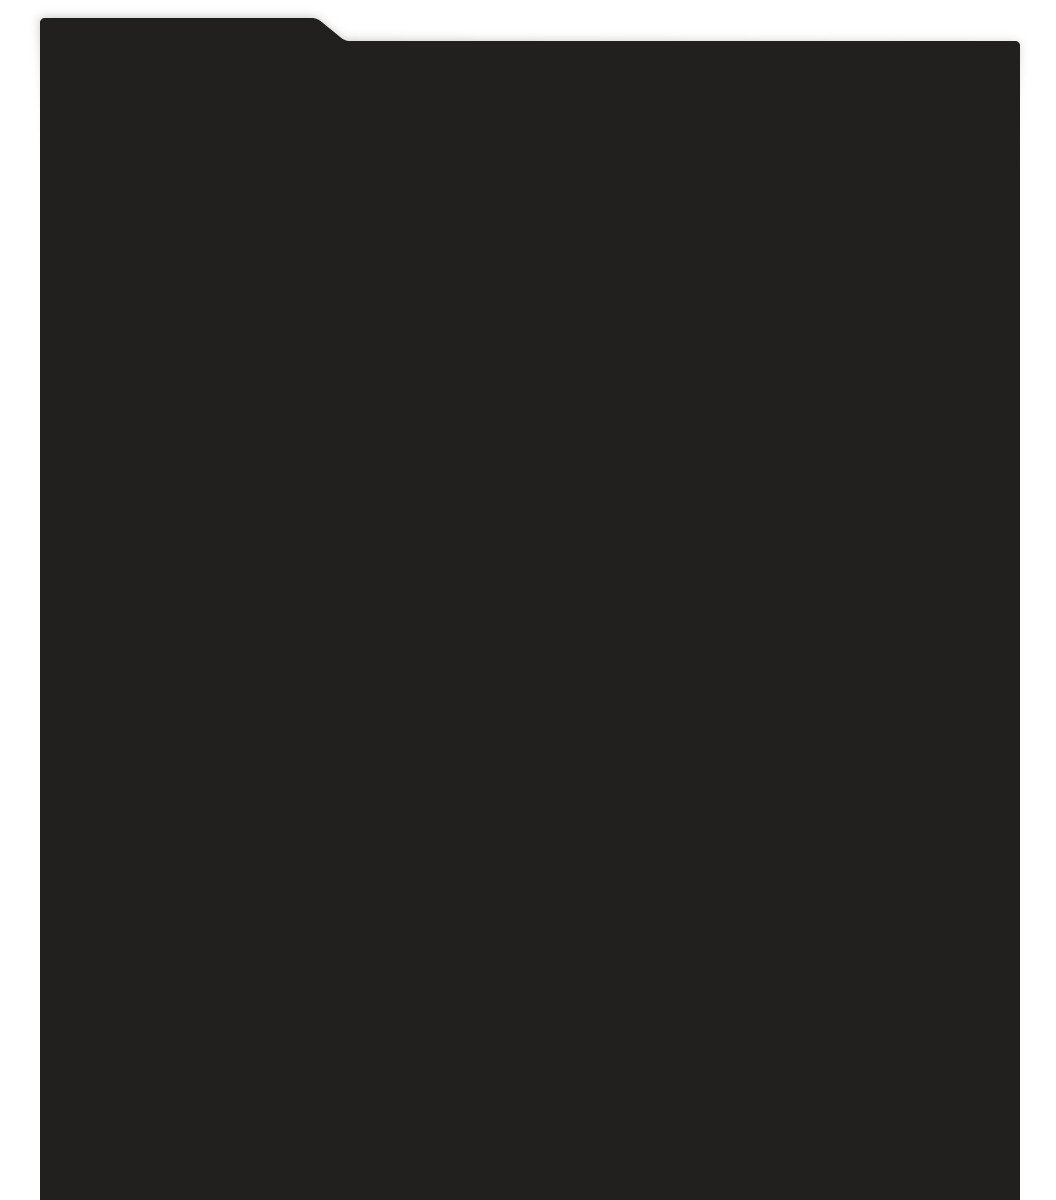
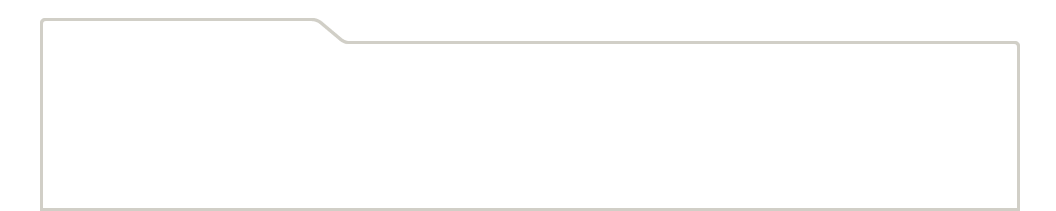
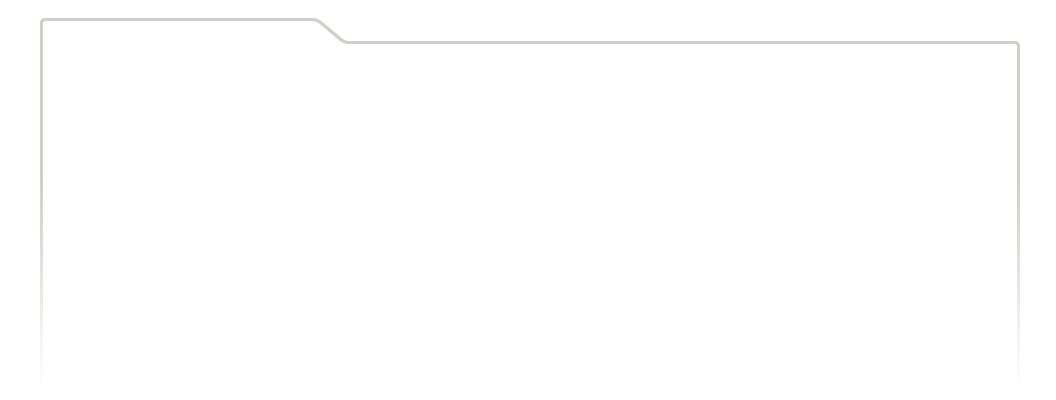
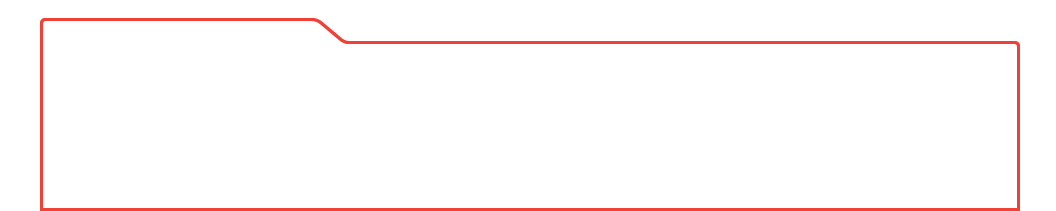
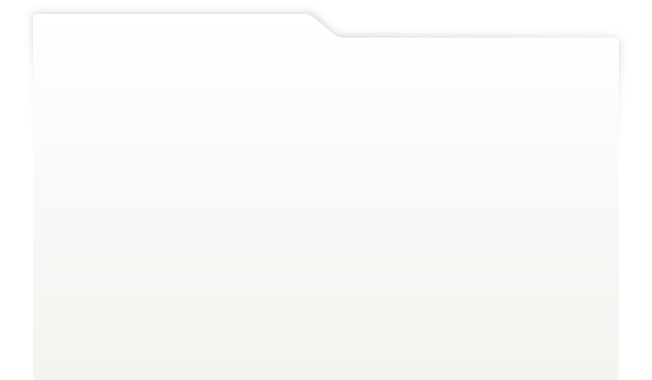
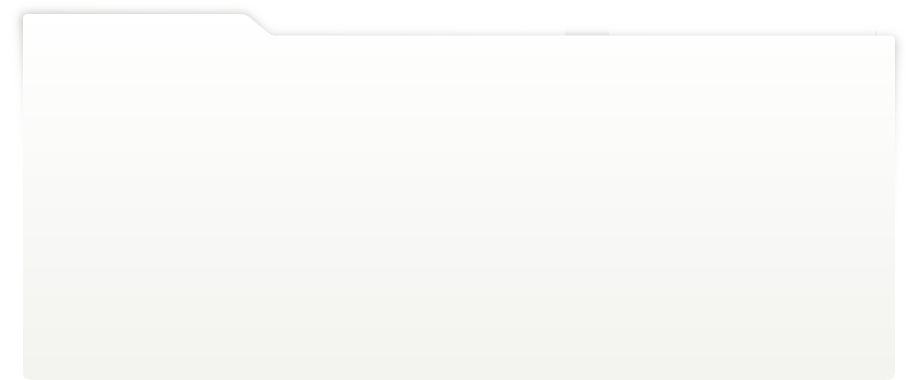
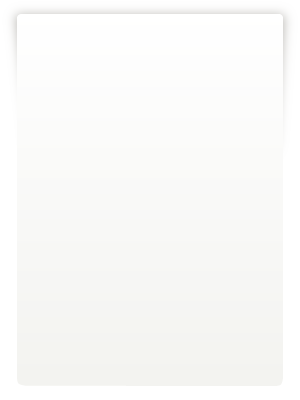
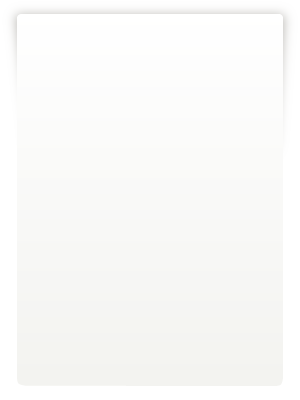
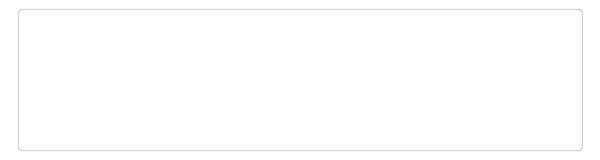
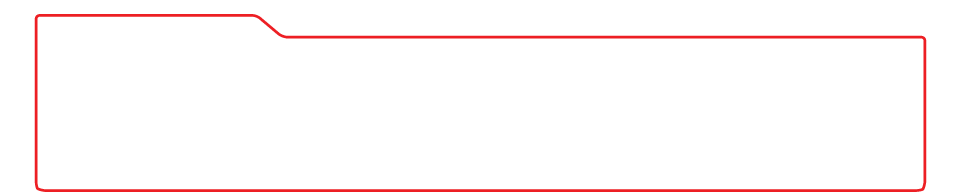
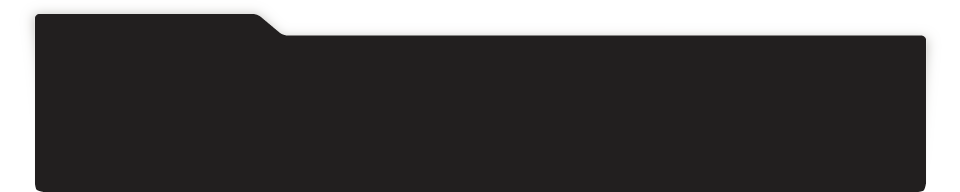
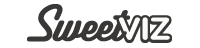
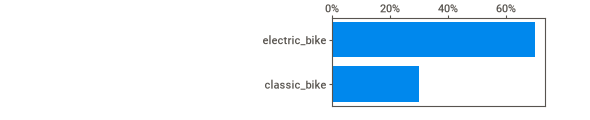
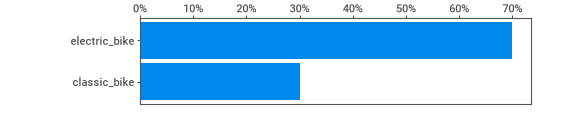
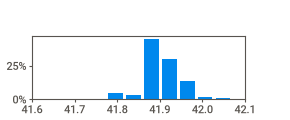
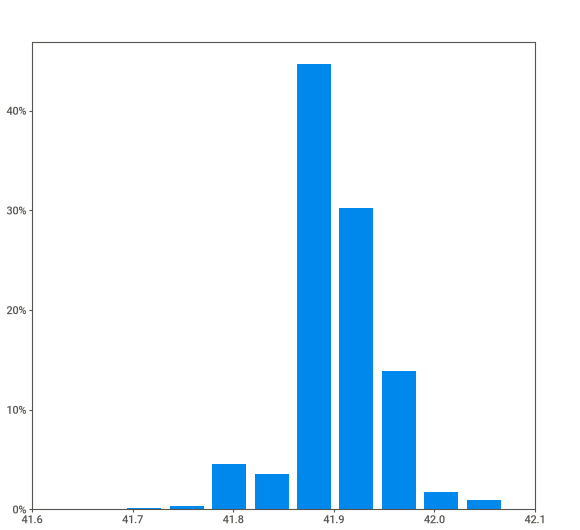
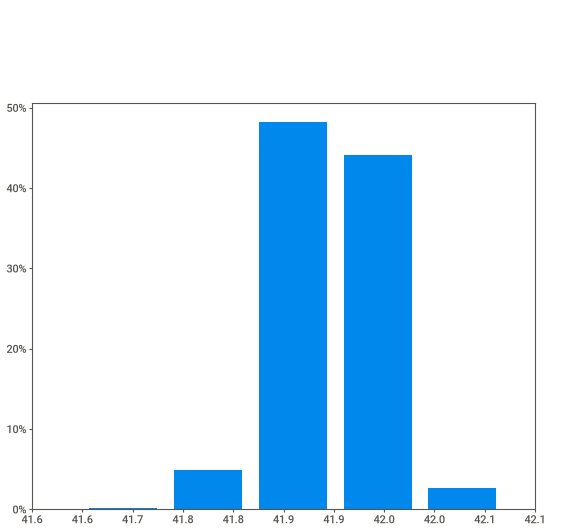
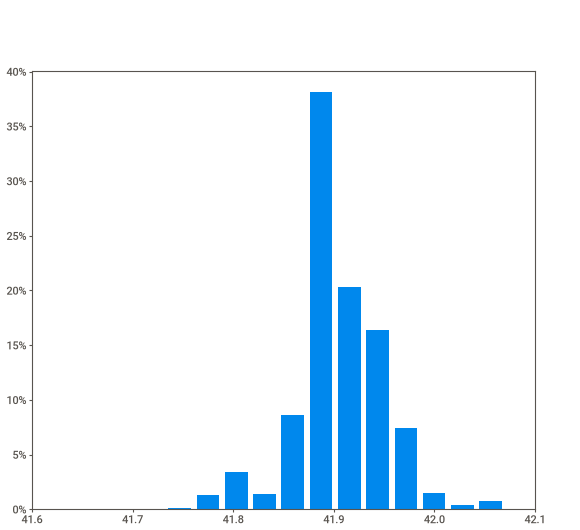
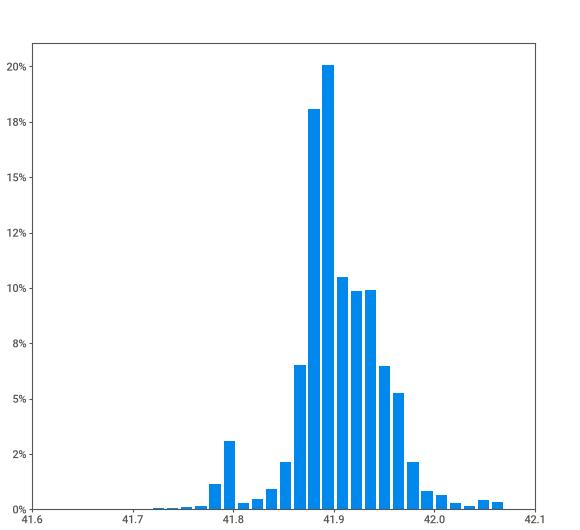
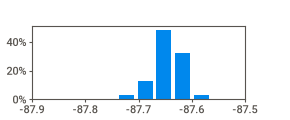
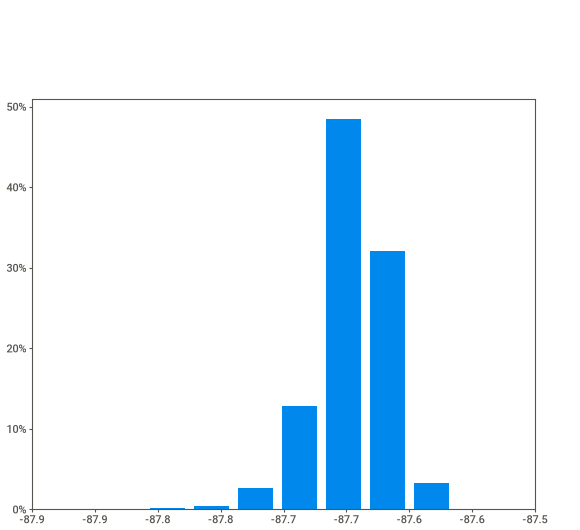
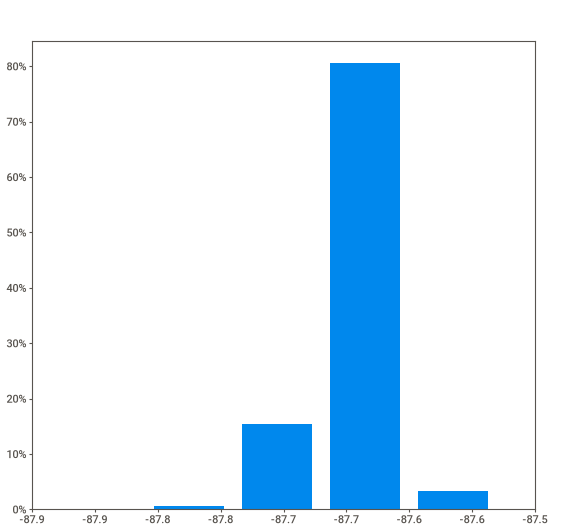
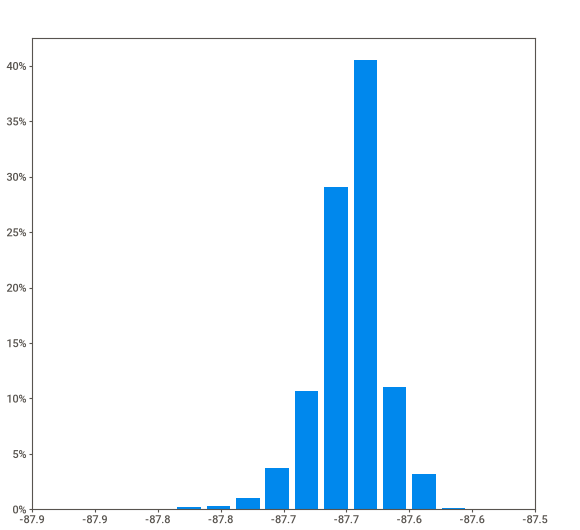
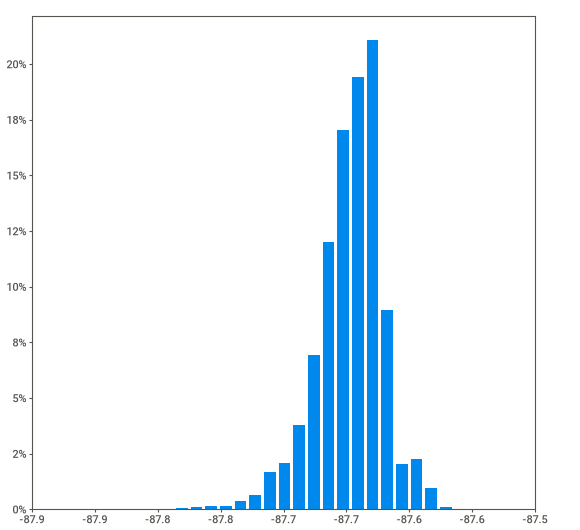
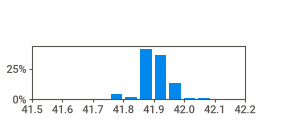
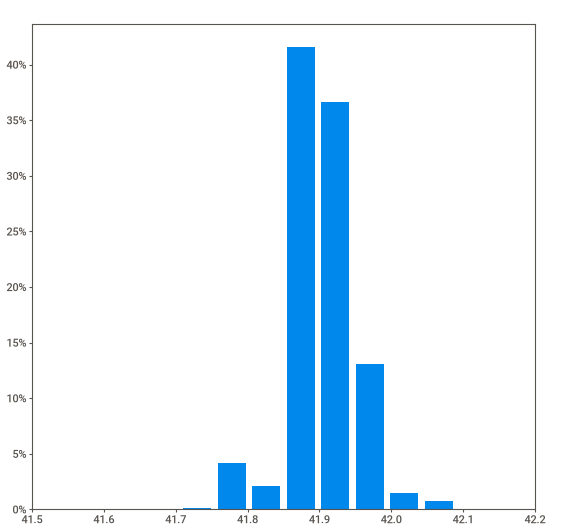
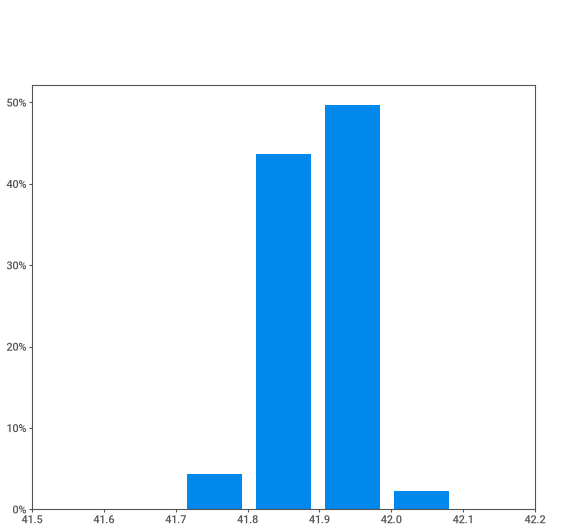
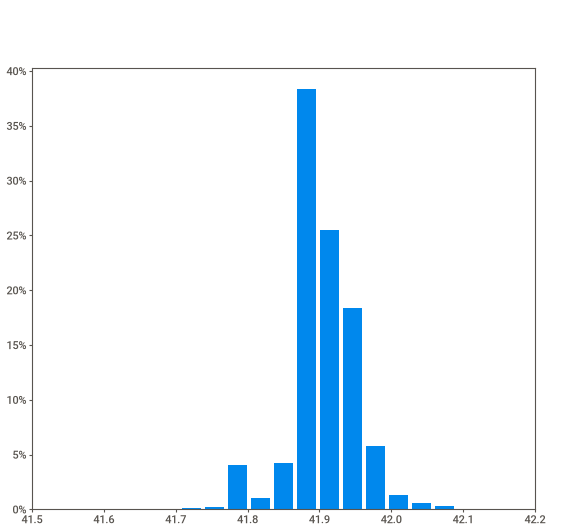
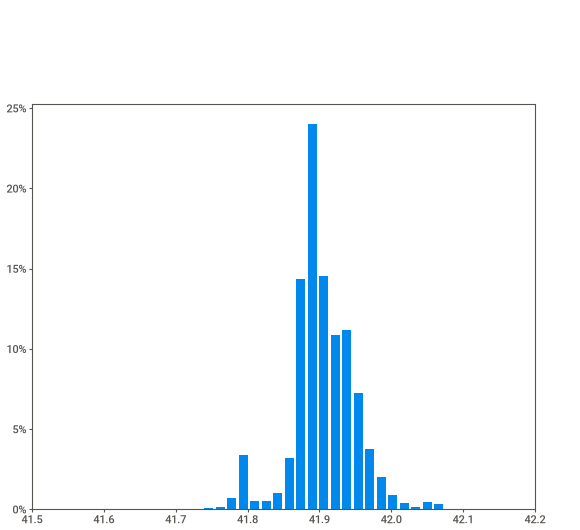
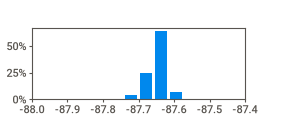
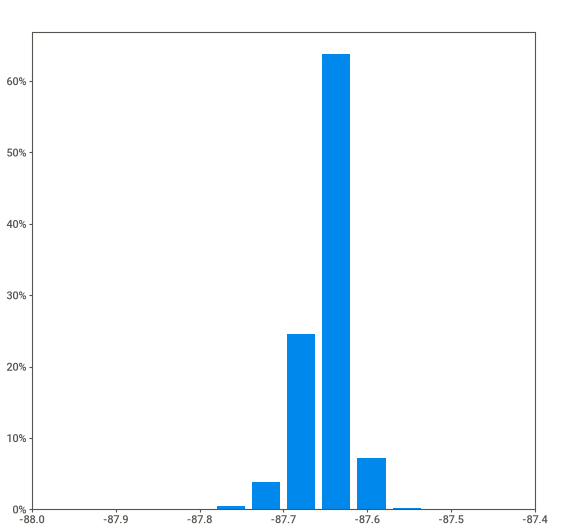
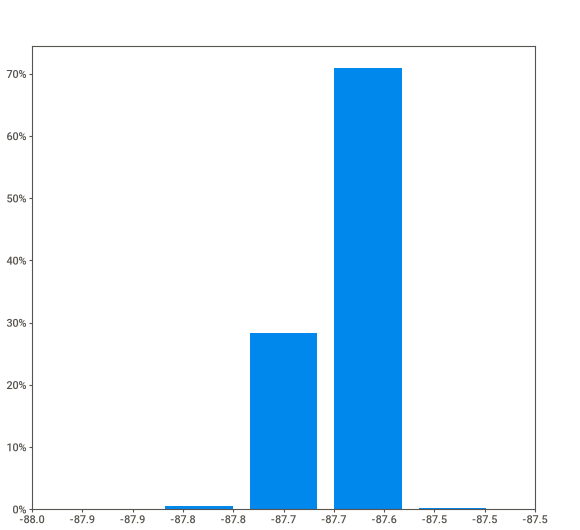
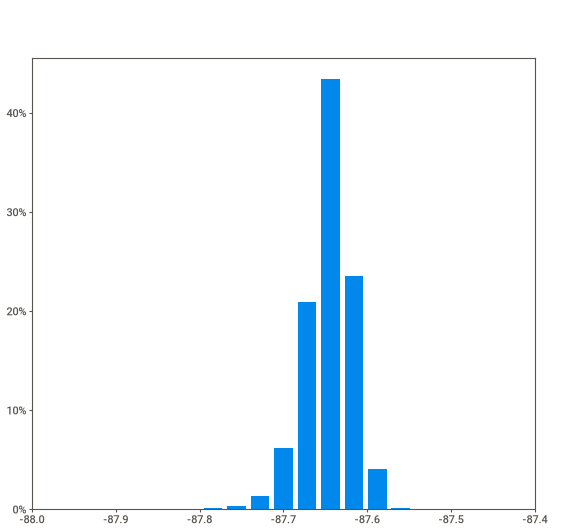
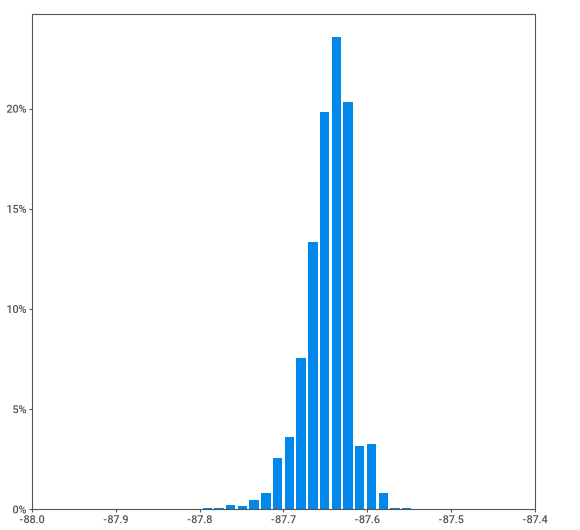
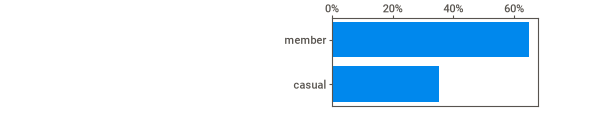
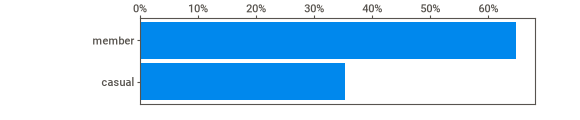
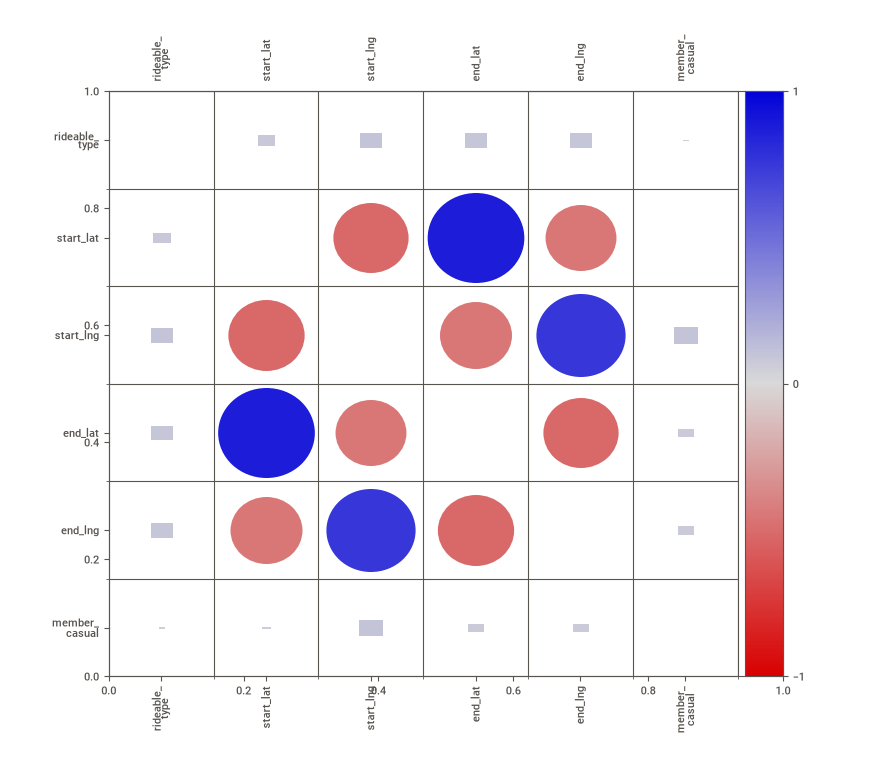
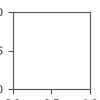

In [ ]:
# Gera um relatório geral de uma amostra do DataFrame

df_sample = df.sample(100_000, random_state=42)

report = sv.analyze(df_sample)

report.show_notebook()

---

## 4. Verificação dos Tipos de Dados

In [ ]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,B0AD82B8A2556E7C,electric_bike,2025-09-01 12:05:13.323,2025-09-01 12:25:19.273,NaN,NaN,NaN,NaN,41.91,-87.63,41.96,-87.64,member
1,DCC4ABF0F7DCCE6A,electric_bike,2025-09-01 01:41:00.775,2025-09-01 01:48:59.228,NaN,NaN,NaN,NaN,41.95,-87.67,41.95,-87.65,member
2,C27785FFE7568433,electric_bike,2025-09-01 07:16:13.921,2025-09-01 07:39:51.831,NaN,NaN,NaN,NaN,41.94,-87.65,41.98,-87.65,member
3,812DB2D3AD2F18EB,electric_bike,2025-09-01 09:31:36.294,2025-09-01 09:49:08.022,NaN,NaN,NaN,NaN,41.98,-87.65,41.94,-87.65,member
4,61F6BD3174DC4E84,electric_bike,2025-09-26 08:51:58.069,2025-09-26 09:07:29.290,NaN,NaN,NaN,NaN,41.90,-87.69,41.87,-87.65,member


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6115982 entries, 0 to 6115981
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             str    
 1   rideable_type       str    
 2   started_at          str    
 3   ended_at            str    
 4   start_station_name  str    
 5   start_station_id    str    
 6   end_station_name    str    
 7   end_station_id      str    
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       str    
dtypes: float64(4), str(9)
memory usage: 606.6 MB


#### `started_at` e `ended_at`

As colunas `started_at` e `ended_at` estão inicialmente armazenadas como `str`. Elas serão convertidas para o tipo `datetime`, pois representam datas e horários e serão utilizadas posteriormente para criar variáveis temporais, como data, hora, dia da semana e mês, além de calcular a duração das viagens.

---

## 5. Conversão e padronização das variáveis de data e hora

In [ ]:
# Convertendo as colunas para datetime

df['started_at'] = pd.to_datetime(
    df['started_at'],
    errors='coerce'
)

df['ended_at'] = pd.to_datetime(
    df['ended_at'],
    errors='coerce'
)

In [17]:
# Checando se a conversão funcionou

df[['started_at', 'ended_at']].dtypes

started_at    datetime64[us]
ended_at      datetime64[us]
dtype: object

---

## 6. Análise de Valores Ausentes

### 6.1 Relatótio de Dados Ausentes

In [80]:
# Conta o número de valores ausentes com base no tipo da váriavel

def missing_data_type(column):

    series = df[column]

    if pd.api.types.is_numeric_dtype(series):
        return series.isna().sum()

    elif pd.api.types.is_datetime64_any_dtype(series):
        return series.isna().sum()

    elif pd.api.types.is_string_dtype(series) or series.dtype == "object":
        return (
            series.isna().sum()
            + series.astype("string").str.strip().eq("").sum()
        )

    return 0

In [81]:
# Cria um DataFrame de relatório sobre os valores ausentes do DataFrame principal
def df_relatorio(df):
    dict_nulls = {}

    for column in df.columns:

        dict_nulls[column] = {
            'Colunas' : column,
            'Valores' : len(df[column]),
            'Valores Faltantes' : missing_data_type(column),
            'Perda de Valores (%)' : (df[column].isnull().sum() / len(df[column])) * 100 
        }

    report = pd.DataFrame(dict_nulls.values())

    return report.sort_values(
        "Valores Faltantes",
        ascending=False
    )

In [86]:
# Exibe o relatório de dados ausentes de forma estilizada para melhor visualização

def tabela_relatorio(report): 
    display(
        report.style
        .hide(axis="index")
        .set_caption("Relatório de Valores Ausentes")
        .set_table_styles([
            {
                "selector": "caption",
                "props": [
                    ("font-size", "16px"),
                    ("font-weight", "bold"),
                    ("text-align", "left"),
                    ("padding", "10px 0")
                ]
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#2F4F4F"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("padding", "8px")
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("padding", "8px"),
                    ("text-align", "left")
                ]
            }
        ])
        .format({
            "Valores": lambda x: f"{x:,.0f}".replace(",", "."),
            "Valores Faltantes": lambda x: f"{x:,.0f}".replace(",", "."), 
            "Perda de Valores (%)": "{:.2f}%"
        })
        .bar(
            subset=["Perda de Valores (%)"],
            cmap="Reds"
        )
        .background_gradient(
            subset=["Valores Faltantes"],
            cmap="Reds"
        )
    )

In [87]:
report_missing_data = df_relatorio(df)
tabela_relatorio(report_missing_data)

Colunas,Valores,Valores Faltantes,Perda de Valores (%)
end_station_name,6.115.982,1.349.937,22.07%
end_station_id,6.115.982,1.349.937,22.07%
start_station_id,6.115.982,1.285.406,21.02%
start_station_name,6.115.982,1.285.406,21.02%
end_lat,6.115.982,5.426,0.09%
end_lng,6.115.982,5.426,0.09%
started_at,6.115.982,0,0.00%
rideable_type,6.115.982,0,0.00%
ride_id,6.115.982,0,0.00%
ended_at,6.115.982,0,0.00%


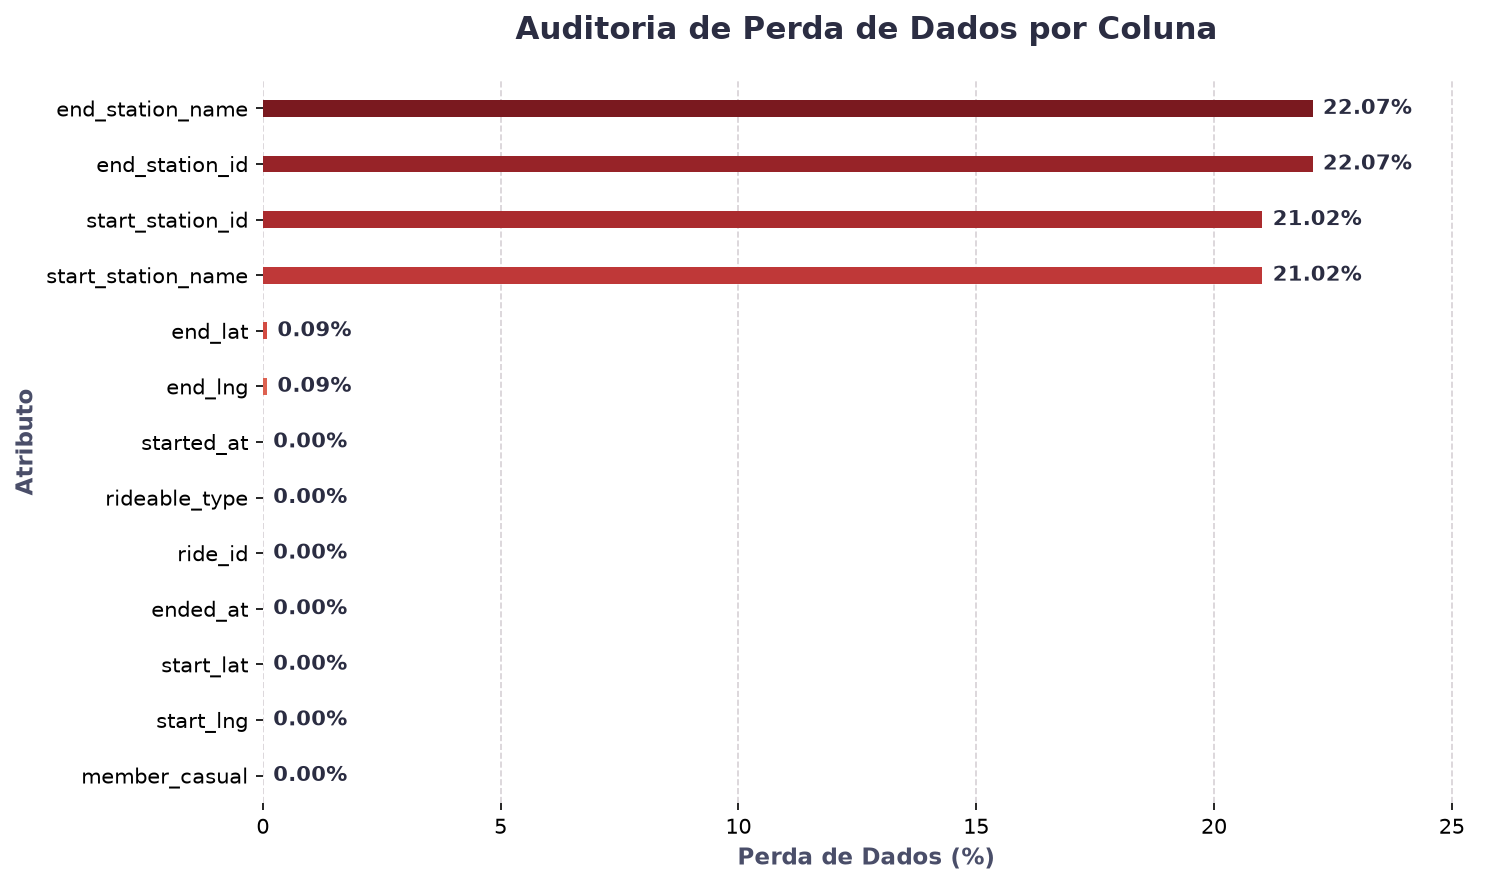

In [29]:
# Exibe gráfico do relatório de dados ausentes

plt.figure(figsize=(10,6), dpi=150)

plt.gca().set_axisbelow(True)
plt.grid(axis='x', linestyle='--', alpha=0.4, color='#9A8C98')

ax = sns.barplot(
    x='Perda de Valores (%)',
    y='Colunas',
    data=report_missing_data,
    hue='Colunas',
    palette='Reds_r',
    legend=False,
    width=0.3
)

for container in ax.containers:
    ax.bar_label(
        container,
        padding=5,
        fontsize=10,
        fontweight='semibold',
        color='#2B2D42',
        fmt='%.2f%%'
    )

plt.title(
    'Auditoria de Perda de Dados por Coluna', 
    fontsize=15, 
    fontweight='bold', 
    color='#2B2D42', 
    pad=20
)
plt.xlabel('Perda de Dados (%)', fontsize=11, fontweight='semibold', color='#4A4E69')
plt.ylabel('Atributo', fontsize=11, fontweight='semibold', color='#4A4E69')
plt.xlim(0, report_missing_data['Perda de Valores (%)'].max() * 1.15)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### 6.2 Checagem Individual de Colunas com Valores Ausentes

In [91]:
# Amostra dos dados ausentes da coluna 'end_station_name'

df[df['end_station_name'].isnull()].head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,B0AD82B8A2556E7C,electric_bike,2025-09-01 12:05:13.323,2025-09-01 12:25:19.273,NaN,NaN,NaN,NaN,41.91,-87.63,41.96,-87.64,member
1,DCC4ABF0F7DCCE6A,electric_bike,2025-09-01 01:41:00.775,2025-09-01 01:48:59.228,NaN,NaN,NaN,NaN,41.95,-87.67,41.95,-87.65,member
2,C27785FFE7568433,electric_bike,2025-09-01 07:16:13.921,2025-09-01 07:39:51.831,NaN,NaN,NaN,NaN,41.94,-87.65,41.98,-87.65,member
3,812DB2D3AD2F18EB,electric_bike,2025-09-01 09:31:36.294,2025-09-01 09:49:08.022,NaN,NaN,NaN,NaN,41.98,-87.65,41.94,-87.65,member
4,61F6BD3174DC4E84,electric_bike,2025-09-26 08:51:58.069,2025-09-26 09:07:29.290,NaN,NaN,NaN,NaN,41.90,-87.69,41.87,-87.65,member


In [92]:
# Amostra dos dados ausentes da coluna 'end_station_id'

df[df['end_station_id'].isnull()].head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,B0AD82B8A2556E7C,electric_bike,2025-09-01 12:05:13.323,2025-09-01 12:25:19.273,NaN,NaN,NaN,NaN,41.91,-87.63,41.96,-87.64,member
1,DCC4ABF0F7DCCE6A,electric_bike,2025-09-01 01:41:00.775,2025-09-01 01:48:59.228,NaN,NaN,NaN,NaN,41.95,-87.67,41.95,-87.65,member
2,C27785FFE7568433,electric_bike,2025-09-01 07:16:13.921,2025-09-01 07:39:51.831,NaN,NaN,NaN,NaN,41.94,-87.65,41.98,-87.65,member
3,812DB2D3AD2F18EB,electric_bike,2025-09-01 09:31:36.294,2025-09-01 09:49:08.022,NaN,NaN,NaN,NaN,41.98,-87.65,41.94,-87.65,member
4,61F6BD3174DC4E84,electric_bike,2025-09-26 08:51:58.069,2025-09-26 09:07:29.290,NaN,NaN,NaN,NaN,41.90,-87.69,41.87,-87.65,member


In [90]:
# Amostra dos dados ausentes da coluna 'start_station_name'

df[df['start_station_name'].isnull()].head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,B0AD82B8A2556E7C,electric_bike,2025-09-01 12:05:13.323,2025-09-01 12:25:19.273,NaN,NaN,NaN,NaN,41.91,-87.63,41.96,-87.64,member
1,DCC4ABF0F7DCCE6A,electric_bike,2025-09-01 01:41:00.775,2025-09-01 01:48:59.228,NaN,NaN,NaN,NaN,41.95,-87.67,41.95,-87.65,member
2,C27785FFE7568433,electric_bike,2025-09-01 07:16:13.921,2025-09-01 07:39:51.831,NaN,NaN,NaN,NaN,41.94,-87.65,41.98,-87.65,member
3,812DB2D3AD2F18EB,electric_bike,2025-09-01 09:31:36.294,2025-09-01 09:49:08.022,NaN,NaN,NaN,NaN,41.98,-87.65,41.94,-87.65,member
4,61F6BD3174DC4E84,electric_bike,2025-09-26 08:51:58.069,2025-09-26 09:07:29.290,NaN,NaN,NaN,NaN,41.90,-87.69,41.87,-87.65,member


In [89]:
# Amostra dos dados ausentes da coluna 'start_station_id'

df[df['start_station_id'].isnull()].head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,B0AD82B8A2556E7C,electric_bike,2025-09-01 12:05:13.323,2025-09-01 12:25:19.273,NaN,NaN,NaN,NaN,41.91,-87.63,41.96,-87.64,member
1,DCC4ABF0F7DCCE6A,electric_bike,2025-09-01 01:41:00.775,2025-09-01 01:48:59.228,NaN,NaN,NaN,NaN,41.95,-87.67,41.95,-87.65,member
2,C27785FFE7568433,electric_bike,2025-09-01 07:16:13.921,2025-09-01 07:39:51.831,NaN,NaN,NaN,NaN,41.94,-87.65,41.98,-87.65,member
3,812DB2D3AD2F18EB,electric_bike,2025-09-01 09:31:36.294,2025-09-01 09:49:08.022,NaN,NaN,NaN,NaN,41.98,-87.65,41.94,-87.65,member
4,61F6BD3174DC4E84,electric_bike,2025-09-26 08:51:58.069,2025-09-26 09:07:29.290,NaN,NaN,NaN,NaN,41.90,-87.69,41.87,-87.65,member


In [88]:
# Amostra dos dados ausentes da coluna 'end_lat'

df[df['end_lat'].isnull()].head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
66846,9905C909001B3F73,classic_bike,2025-09-06 09:50:16.336,2025-09-07 10:50:06.364,Dearborn Pkwy & Delaware Pl,CHI00306,NaN,NaN,41.898969,-87.629912,NaN,NaN,casual
67192,DE4A219B1205788C,classic_bike,2025-09-16 15:58:46.084,2025-09-17 16:58:38.814,State St & 54th St,CHI01078,NaN,NaN,41.796642,-87.625923,NaN,NaN,casual
67274,CCC64EB0C9099A7F,classic_bike,2025-09-18 08:59:49.629,2025-09-19 09:59:45.331,Knox Ave & Marquette Ave,CHI01847,NaN,NaN,41.771140,-87.737740,NaN,NaN,casual
67342,AAE605E4EE8631DE,classic_bike,2025-09-26 18:34:57.900,2025-09-27 19:34:54.517,Pulaski Rd & 51st St,CHI01876,NaN,NaN,41.800434,-87.724750,NaN,NaN,casual
67344,9238F50379FBCC62,classic_bike,2025-09-26 12:22:42.614,2025-09-27 13:22:39.022,Winthrop Ave & Lawrence Ave,CHI00391,NaN,NaN,41.968812,-87.657659,NaN,NaN,casual


In [87]:
# Amostra dos dados ausentes da coluna 'end_lng'

df[df['end_lng'].isnull()].head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
66846,9905C909001B3F73,classic_bike,2025-09-06 09:50:16.336,2025-09-07 10:50:06.364,Dearborn Pkwy & Delaware Pl,CHI00306,NaN,NaN,41.898969,-87.629912,NaN,NaN,casual
67192,DE4A219B1205788C,classic_bike,2025-09-16 15:58:46.084,2025-09-17 16:58:38.814,State St & 54th St,CHI01078,NaN,NaN,41.796642,-87.625923,NaN,NaN,casual
67274,CCC64EB0C9099A7F,classic_bike,2025-09-18 08:59:49.629,2025-09-19 09:59:45.331,Knox Ave & Marquette Ave,CHI01847,NaN,NaN,41.771140,-87.737740,NaN,NaN,casual
67342,AAE605E4EE8631DE,classic_bike,2025-09-26 18:34:57.900,2025-09-27 19:34:54.517,Pulaski Rd & 51st St,CHI01876,NaN,NaN,41.800434,-87.724750,NaN,NaN,casual
67344,9238F50379FBCC62,classic_bike,2025-09-26 12:22:42.614,2025-09-27 13:22:39.022,Winthrop Ave & Lawrence Ave,CHI00391,NaN,NaN,41.968812,-87.657659,NaN,NaN,casual


### 6.3 Comparação Entre Colunas com Dados Ausentes

In [77]:
# Localiza todas as colunas que têm valores ausentes

cols_missing_data = report_missing_data[
    report_missing_data["Valores Faltantes"] != 0
]['Colunas']

In [78]:
# Armazena os índices dos valores ausentes de cada coluna

null_indexes = {
    col: set(df.index[df[col].isnull()])
    for col in cols_missing_data
}

In [79]:
# Compara se os registros ausentes são exatamente iguais

for i, col1 in enumerate(cols_missing_data):

    for col2 in cols_missing_data[i + 1:]:

        if null_indexes[col1] == null_indexes[col2]:

            print(
                f"`{col1}` e `{col2}` possuem valores ausentes "
                "nos mesmos registros."
            )

`end_station_name` e `end_station_id` possuem valores ausentes nos mesmos registros.
`start_station_id` e `start_station_name` possuem valores ausentes nos mesmos registros.
`end_lat` e `end_lng` possuem valores ausentes nos mesmos registros.


In [86]:
# Compara a contenção dos valores ausentes

if null_indexes["end_lat"].issubset(
    null_indexes["end_station_name"]
):
    print(
        "Todos os valores ausentes de `end_lat` "
        "estão contidos nos de `end_station_name`."
    )

if null_indexes["start_station_id"].issubset(
    null_indexes["end_station_name"]
):
    print(
        "Todos os valores ausentes de `start_station_name` "
        "estão contidos nos de `end_station_name`."
    )

if null_indexes["end_lat"].issubset(
    null_indexes["start_station_id"]
):
    print(
        "Todos os valores ausentes de `end_lat"
        "estão contidos nos de `start_station_name`."
    )

Todos os valores ausentes de `end_lat` estão contidos nos de `end_station_name`.


In [85]:
# Compara os registros ausentes das estações de início e fim

start_station_null = null_indexes["start_station_name"]
end_station_null = null_indexes["end_station_name"]

intersection = start_station_null & end_station_null

print(
    f"Registros com `start_station` e `end_station` ausentes: "
    f"{len(intersection):,}".replace(",", ".")
)

Registros com `start_station` e `end_station` ausentes: 577.879


#### Análise dos valores ausentes

`start_station_name`/`start_station_id` e `end_station_name`/`end_station_id` possuem ausências nos mesmos registros e serão analisados em conjunto.

`end_station_name` e `end_station_id` possuem **1.349.937** ausências, enquanto `end_lat` e `end_lng` possuem apenas **5.426**, todas contidas nas ausências da estação de destino. Dessa forma, as coordenadas disponíveis poderão ser utilizadas para tentar recuperar as estações de destino.

A mesma abordagem poderá ser aplicada às estações de início, utilizando `start_lat` e `start_lng` para tentar recuperar as informações ausentes.

Também foram identificados **577.879 registros** com as estações de início e término simultaneamente ausentes.


### 6.4 Investigação das Cordenadas e suas Estações Correspondentes

#### 6.4.1 Comparação Entre Ecoordenadas de Inicio e de Fim (start e end)

In [30]:
# Criar tabelas com coordenada + nome da estação


start_coords = (
    df[["start_lat", "start_lng", "start_station_name"]]
    .dropna(subset=["start_lat", "start_lng", "start_station_name"])
    .drop_duplicates()
)

end_coords = (
    df[["end_lat", "end_lng", "end_station_name"]]
    .dropna(subset=["end_lat", "end_lng", "end_station_name"])
    .drop_duplicates()
)

In [31]:
# Quantidade de coordenadas únicas

start_unique = start_coords[["start_lat", "start_lng"]].drop_duplicates()
end_unique = end_coords[["end_lat", "end_lng"]].drop_duplicates()

print("Coordenadas únicas:")
print(f"START: {len(start_unique):,}")
print(f"END:   {len(end_unique):,}")

Coordenadas únicas:
START: 133,703
END:   2,143


In [32]:
# Quantos nomes diferentes cada coordenada possui?

start_consistency = (
    start_coords
    .groupby(["start_lat", "start_lng"])["start_station_name"]
    .nunique()
    .reset_index(name="qtd_nomes")
)

end_consistency = (
    end_coords
    .groupby(["end_lat", "end_lng"])["end_station_name"]
    .nunique()
    .reset_index(name="qtd_nomes")
)


In [33]:
# Classifica as coordenadas por nível de consistência

def classificar_consistencia(qtd):
    if qtd == 1:
        return "Consistente"
    else:
        return "Ambígua"


start_consistency["consistencia"] = (
    start_consistency["qtd_nomes"]
    .apply(classificar_consistencia)
)

end_consistency["consistencia"] = (
    end_consistency["qtd_nomes"]
    .apply(classificar_consistencia)
)

In [34]:
# Resumo START

start_summary = (
    start_consistency["consistencia"]
    .value_counts()
    .rename_axis("consistencia")
    .reset_index(name="quantidade")
)

start_summary["percentual"] = (
    start_summary["quantidade"]
    / len(start_consistency)
    * 100
)

In [35]:
# 6. Resumo END

end_summary = (
    end_consistency["consistencia"]
    .value_counts()
    .rename_axis("consistencia")
    .reset_index(name="quantidade")
)

end_summary["percentual"] = (
    end_summary["quantidade"]
    / len(end_consistency)
    * 100
)

In [36]:
#  Mostra os resultados

print("\n--- START ---")
print(start_summary)

print("\n--- END ---")
print(end_summary)


--- START ---
  consistencia  quantidade  percentual
0  Consistente      133639   99.952133
1      Ambígua          64    0.047867

--- END ---
  consistencia  quantidade  percentual
0  Consistente        2091   97.573495
1      Ambígua          52    2.426505


##### Serão utilizadas as coordenadas *START* como referência

- As coordenadas de início (`start_lat` e `start_lng`) apresentaram maior consistência na identificação das estações do que as coordenadas de destino (`end_lat` e `end_lng`). Por isso, serão utilizadas como referência para auxiliar no preenchimento das coordenadas de destino ausentes.

- Essa escolha não significa que as coordenadas *START* sejam sempre exatas ou imutáveis. Uma mesma estação pode apresentar pequenas variações nas coordenadas ao longo dos registros e, em alguns casos, valores atípicos. Por isso, será utilizada uma coordenada representativa da estação, em vez de assumir que todas as coordenadas observadas são idênticas.

#### 6.4.2 `start_lat`e `start_lng`

In [19]:
# Criar uma tabela de referência com coordenadas por estação 

start_station_reference = (
    df[
        df["start_lat"].notna()
        & df["start_lng"].notna()
        & df["start_station_name"].notna()
    ][
        ["start_lat", "start_lng", "start_station_name", "start_station_id"]
    ]
    .drop_duplicates()
)

start_station_reference.head()

,start_lat,start_lng,start_station_name,start_station_id
8,41.888960,-87.649730,Peoria St & Kinzie St,CHI02098
53,41.961524,-87.691177,Campbell Ave & Montrose Ave,CHI00214
148,41.943034,-87.687288,Western Ave & Roscoe St,CHI00614
175,41.922695,-87.697153,California Ave & Milwaukee Ave,CHI00307
180,41.862378,-87.651062,Morgan Ave & 14th Pl,CHI00261


In [20]:
## Exibe quantas coordenadas diferentes existem 

start_coordinate_counts = (
    df[
        df["start_lat"].notna()
        & df["start_lng"].notna()
    ]
    .groupby(["start_lat", "start_lng"])
    .size()
    .sort_values(ascending=False)
)

start_coordinate_counts.head(20)

start_lat  start_lng 
41.892278  -87.612043    68029
41.890000  -87.630000    49570
41.880000  -87.640000    47154
           -87.630000    45363
41.910000  -87.630000    42013
41.900000  -87.630000    38082
41.880958  -87.616743    37971
41.890000  -87.620000    36236
41.900960  -87.623777    34599
41.911722  -87.626804    32506
41.890000  -87.640000    29760
41.896617  -87.628579    29438
41.882409  -87.639767    29357
41.940000  -87.650000    28505
41.883380  -87.641170    27836
41.912133  -87.634656    27800
41.926277  -87.630834    26739
41.903222  -87.634324    26486
41.930000  -87.650000    26455
41.940000  -87.640000    25891
dtype: int64

In [ ]:
# Exibe quantas coordenadas correspondem a 1 ou mais nomes de estações

start_coordinate_station = (
    df[
        df["start_lat"].notna()
        & df["start_lng"].notna()
        & df["start_station_name"].notna()
    ]
    .groupby(["start_lat", "start_lng"])["start_station_name"]
    .nunique()
)

start_coordinate_station.value_counts().sort_index()

start_station_name
1    133639
2        57
3         6
4         1
Name: count, dtype: int64

In [ ]:
# Calcula a quantidade de coordenadas que referem-se a cada nome de estação

station_check = (
    start_station_reference
    .groupby("start_station_name")
    .agg(
        qtd_coordenadas=("start_lat", "nunique"),
        qtd_ids=("start_station_id", "nunique")
    )
    .reset_index()
)

In [64]:
# Exibe o numero de coordenadas por estação

station_check["qtd_coordenadas"].value_counts().sort_index()

qtd_coordenadas
1       606
2       226
3       127
4        74
5        49
       ... 
880       1
906       1
978       1
1047      1
1359      1
Name: count, Length: 333, dtype: int64

In [ ]:
# Exibe quantas coordenadas correspondem a 1 ou mais ids de estações

station_check["qtd_ids"].value_counts().sort_index()

qtd_ids
1    1929
2      62
3       1
Name: count, dtype: int64

In [ ]:
# Filtra o station_check para encontrar apenas os nomes de estação que têm, 
# ao mesmo tempo, mais de uma coordenada e mais de um ID

station_check[
    (station_check["qtd_coordenadas"] > 1) &
    (station_check["qtd_ids"] > 1)
]

,start_station_name,qtd_coordenadas,qtd_ids
19,Albany Ave & 16th St,16,2
21,Albany Ave & Belmont Ave,49,2
27,Archer Ave & 43rd St,2,2
135,California Ave & Winona St,42,2
145,Campbell Ave & Augusta Blvd,147,2
...,...,...,...
1943,Western Ave & Gunnison St,83,2
1945,Western Ave & Lake St,11,2
1956,Whipple St & Roosevelt Rd,17,2
1960,Wilton Ave & Diversey Pkwy,105,2


##### Será utilizado o *ID* em vez do *nome*

- O `station_id` será utilizado como chave principal para identificar as estações, pois apresentou maior estabilidade do que o *nome* da estação. A maioria dos nomes está associada a um único *ID*, enquanto um mesmo *nome* pode aparecer com diferentes coordenadas e, em alguns casos, diferentes *IDs*.

- Ainda existem exceções, portanto o `station_id` não será tratado como uma chave perfeitamente imutável. A referência das coordenadas será construída considerando essa variação e evitando assumir uma relação rígida de uma estação para uma única coordenada.

#### 6.4.3 Criando Coordenada de Referência por `start_station_id`

In [ ]:
# Pega, para cada ID, a coordenada START que aparece com maior frequência

start_coord_reference = (
    df.dropna(subset=["start_station_id", "start_lat", "start_lng"])
    .groupby(["start_station_id", "start_lat", "start_lng"])
    .size()
    .reset_index(name="qtd")
    .sort_values(
        ["start_station_id", "qtd"],
        ascending=[True, False]
    )
    .drop_duplicates("start_station_id")
)

In [66]:
start_coord_reference.head()

,start_station_id,start_lat,start_lng,qtd
0,CHI02331,41.884390,-87.635170,643
1,000-CHI01831,41.877161,-87.706134,9
38,CHI00005,41.912616,-87.681469,4438
141,CHI00213,41.815491,-87.702441,21
154,CHI00214,41.961524,-87.691177,3567


In [ ]:
# Pega, para cada ID, a coordenada END que aparece com maior frequência

end_coord_reference = (
    df.dropna(subset=["end_station_id", "end_lat", "end_lng"])
    .groupby(["end_station_id", "end_lat", "end_lng"])
    .size()
    .reset_index(name="qtd")
    .sort_values(
        ["end_station_id", "qtd"],
        ascending=[True, False]
    )
    .drop_duplicates("end_station_id")
)

In [68]:
# Compara com as duas referências

coordinate_validation = start_coord_reference.merge(
    end_coord_reference,
    left_on="start_station_id",
    right_on="end_station_id",
    how="inner"
)

In [69]:
# Verifica se as coordenadas predominantes são iguais

coordinate_validation["mesma_coordenada"] = (
    (coordinate_validation["start_lat"] == coordinate_validation["end_lat"]) &
    (coordinate_validation["start_lng"] == coordinate_validation["end_lng"])
)

In [70]:
coordinate_validation["mesma_coordenada"].value_counts()

mesma_coordenada
True     1977
False       3
Name: count, dtype: int64

##### A coordenada predominante de START será usada como referência para a estação.

- A coordenada **START** mais frequente por `station_id` foi utilizada como referência para identificar as estações. Essa escolha foi validada comparando a coordenada predominante de **START** com a coordenada predominante de **END** para os mesmos IDs, obtendo concordância em **1.977 de 1.980** estações analisadas (**99,85%**).

- Essa referência foi utilizada para auxiliar na recuperação dos valores ausentes de identificação das estações, sem substituir valores que já estavam preenchidos.

### 6.5 Tratando Valores Ausentes

####  6.5.1 Uso das Coordenadas Prodiminantes de START

In [ ]:
# Cria uma referência com a coordenada e o nome mais frequentes de cada estação,
# usando o start_station_id como chave para identificar cada estação.

station_reference = (
    df.dropna(
        subset=[
            "start_station_id",
            "start_station_name",
            "start_lat",
            "start_lng"
        ]
    )
    .groupby(
        [
            "start_station_id",
            "start_station_name",
            "start_lat",
            "start_lng"
        ]
    )
    .size()
    .reset_index(name="qtd")
    .sort_values("qtd", ascending=False)
    .drop_duplicates("start_station_id")
)

In [ ]:
# Cria uma estrutura de busca espacial com as coordenadas das estações
# para encontrar rapidamente a estação mais próxima de cada coordenada.

tree = cKDTree(
    station_reference[
        ["start_lat", "start_lng"]
    ].to_numpy()
)

In [ ]:
# Seleciona os registros que possuem as coordenadas START,
# mas estão sem o ID da estação.

mask_start = (
    df["start_station_id"].isna()
    & df["start_lat"].notna()
    & df["start_lng"].notna()
)

dist_start, idx_start = tree.query(
    df.loc[mask_start, ["start_lat", "start_lng"]].to_numpy()
)

df.loc[mask_start, "start_station_id"] = (
    station_reference.iloc[idx_start]["start_station_id"].to_numpy()
)

df.loc[mask_start, "start_station_name"] = (
    station_reference.iloc[idx_start]["start_station_name"].to_numpy()
)

In [ ]:
# Seleciona os registros que possuem as coordenadas END,
# mas estão sem o ID da estação.

mask_end = (
    df["end_station_id"].isna()
    & df["end_lat"].notna()
    & df["end_lng"].notna()
)

dist_end, idx_end = tree.query(
    df.loc[mask_end, ["end_lat", "end_lng"]].to_numpy()
)

df.loc[mask_end, "end_station_id"] = (
    station_reference.iloc[idx_end]["start_station_id"].to_numpy()
)

df.loc[mask_end, "end_station_name"] = (
    station_reference.iloc[idx_end]["start_station_name"].to_numpy()
)

In [ ]:
# Remove as colunas auxiliares de referência criadas durante o processo de imputação.


df = df.drop(
    columns=["start_lat_ref", "start_lng_ref"],
    errors="ignore"
)

In [ ]:
# Gera um novo relatório de valores ausentes após o tratamento dos dados
# para verificar quais valores ainda permanecem faltantes.

report_new_df = df_relatorio(df)
tabela_relatorio(report_new_df)

Colunas,Valores,Valores Faltantes,Perda de Valores (%)
end_station_name,6.115.982,5.426,0.09%
end_lat,6.115.982,5.426,0.09%
end_lng,6.115.982,5.426,0.09%
end_station_id,6.115.982,5.426,0.09%
ride_id,6.115.982,0,0.00%
start_station_name,6.115.982,0,0.00%
ended_at,6.115.982,0,0.00%
started_at,6.115.982,0,0.00%
rideable_type,6.115.982,0,0.00%
start_lat,6.115.982,0,0.00%


##### Tratamento dos valores ausentes restantes

- Após o processo de imputação, restaram apenas **5.426 registros** com valores ausentes nas colunas `end_station_name`, `end_station_id`, `end_lat` e `end_lng`. Esse volume representa aproximadamente **0,09% do total de 6.115.982 registros**.

- Como esses registros não possuem informações suficientes para uma recuperação confiável, eles serão removidos do conjunto de dados. A exclusão de uma parcela tão pequena dos dados não deverá comprometer as análises posteriores.


#### 6.5.2 Removendo Registros Restantes

In [108]:
# Remove os registros que ainda possuem valores ausentes.

df = df.dropna()

In [109]:
# Gera um novo relatório de valores ausentes após o tratamento dos dados

report_no_missing_data = df_relatorio(df)
tabela_relatorio(report_no_missing_data)

c:\Aprendendo_a_Programar\Analise_de_Dados_Google\Estudo de Caso I\Analise_Cyclistic\.venv\Lib\site-packages\pandas\io\formats\style.py:4438: RuntimeWarning: invalid value encountered in scalar divide
  end = (x - left) / (right - left)


Colunas,Valores,Valores Faltantes,Perda de Valores (%)
ride_id,6.110.556,0,0.00%
rideable_type,6.110.556,0,0.00%
started_at,6.110.556,0,0.00%
ended_at,6.110.556,0,0.00%
start_station_name,6.110.556,0,0.00%
start_station_id,6.110.556,0,0.00%
end_station_name,6.110.556,0,0.00%
end_station_id,6.110.556,0,0.00%
start_lat,6.110.556,0,0.00%
start_lng,6.110.556,0,0.00%
